In [1]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATH = "../aca-butterflies"
NUM_CLASSES = 75
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_EPOCHS = 30
PATIENCE = 7

# from our dataset, calculated at 0_EDA.ipynb file
RGB_MEAN = [0.4790, 0.4646, 0.3369]
RGB_STD = [0.2560, 0.2462, 0.2558]

# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [2]:
from dataset_utilsCNN import ButterflyDataset

In [3]:
def build_transforms(mean, std, image_size=IMAGE_SIZE):
    train = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    
    return train, val

In [4]:
train_transform, val_transform = build_transforms(RGB_MEAN, RGB_STD)

img_dir = os.path.join(PATH, "train")
df = pd.read_csv(os.path.join(PATH, "train.csv"))

df_train, df_val = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)

all_classes   = sorted(df["label"].unique())
idx_to_class  = {cls: idx for idx, cls in enumerate(all_classes)}

train_dataset = ButterflyDataset(df_train, img_dir, train_transform, idx_to_class)
val_dataset   = ButterflyDataset(df_val, img_dir, val_transform, idx_to_class)

# AJUSTE PARA ESTABILIDADE NO MAC M2:
train_loader = data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,            # Alterar para 0 para evitar Broken pipe
    pin_memory=False,         # Correto: Manter False para Memória Unificada
    # persistent_workers e prefetch_factor não são necessários com num_workers=0
)

val_loader = data.DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,            # Alterar para 0
    pin_memory=False
)

print(len(df_train))
print(len(df_val))

4159
1040


In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, 
                num_epochs=NUM_EPOCHS, patience=PATIENCE, device=DEVICE, run_name="experiment"):
    
    counter_early_stopper = 0
    best_acc = 0.0
    best_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    
    history = {"train_loss": [], "val_loss": [], "train_acc":  [], "val_acc":  [], "lr": []}

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        current_lr = optimizer.param_groups[0]['lr']
        history["lr"].append(current_lr)
        
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, *_ = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        # Print formatado para facilitar a leitura no terminal/VS Code
        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")
        
        # Critério de Melhoria: Prioridade à Accuracy, depois à Loss
        if vl_acc > best_acc + 1e-4:
            best_acc = vl_acc
            best_loss = vl_loss
            best_weights = copy.deepcopy(model.state_dict())
            counter_early_stopper = 0
        elif vl_loss < best_loss - 1e-4:
            best_loss = vl_loss
            counter_early_stopper = 0
        else:
            counter_early_stopper += 1
            if counter_early_stopper >= patience:
                print(f"\n[Early Stopping] {run_name} parado na época {epoch}")
                break

    elapsed_in_min = (time.time() - t0) / 60
    model.load_state_dict(best_weights)
    return model, history, elapsed_in_min

In [7]:
def compute_metrics(labels, preds, name=""):
    acc = accuracy_score(labels, preds)
    f1_mac = f1_score(labels, preds, average="macro",  zero_division=0)
    f1_wei = f1_score(labels, preds, average="weighted", zero_division=0)

    print(f"{name}->Accuracy : {acc:.4f}")
    print(f"{name}->F1 (macro) : {f1_mac:.4f}")
    print(f"{name}->F1(weighted) : {f1_wei:.4f}")
    return {"accuracy": acc, "f1_macro": f1_mac, "f1_weighted": f1_wei}

def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()
    
def plot_confusion_matrix(labels, preds, idx_to_class, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)

    errors_per_class = cm.sum(axis=1) - cm.diagonal()
    top25_idx = np.argsort(errors_per_class)[-25:][::-1]

    cm_top25     = cm[np.ix_(top25_idx, top25_idx)]
    class_names  = [idx_to_class[i] for i in top25_idx]

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm_top25, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.4, cbar_kws={"shrink": 0.7})
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_per_class_accuracy(labels, preds, idx_to_class):
    cm = confusion_matrix(labels, preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    sorted_idx   = np.argsort(per_class_acc)
    sorted_acc   = per_class_acc[sorted_idx]
    sorted_names = [idx_to_class[i] for i in sorted_idx]

    fig, ax = plt.subplots(figsize=(10, 18))
    colors = ["tomato" if a < 0.5 else "steelblue" for a in sorted_acc]
    ax.barh(sorted_names, sorted_acc, color=colors, edgecolor="white")
    ax.set_xlabel("Per-class Accuracy")
    ax.set_title("Per-class Accuracy")
    ax.set_xlim(0, 1.0)
    plt.tight_layout()
    plt.show()


In [8]:
class ModernLeNet(nn.Module):
    def __init__(self, input_channels=3, num_classes=NUM_CLASSES):
        super(ModernLeNet, self).__init__()
        
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        
        # Ajustado para 224x224: 64 canais * 56 * 56 pixels
        self.fc1 = nn.Linear(64 * 56 * 56, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Cada F.max_pool2d com kernel 2 reduz a dimensão para metade
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2) # 224 -> 112
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2) # 112 -> 56
        
        x = x.view(x.size(0), -1) # Flatten: [Batch, 64*56*56]
        
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [9]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            # Conv 1: Captura bordas e blobs [cite: 537]
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv 2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv 3, 4 e 5: Extração de texturas e partes de objetos [cite: 538, 539]
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes), # Camada final para as 75 classes [cite: 542]
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [10]:
class VGG16(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(VGG16, self).__init__()
        # Configuração clássica de blocos VGG [cite: 588]
        self.features = self._make_layers([
            64, 64, 'M', 
            128, 128, 'M', 
            256, 256, 256, 'M', 
            512, 512, 512, 'M', 
            512, 512, 512, 'M'
        ])
        # Classifier adaptado ao dataset (5.200 imagens, 75 classes)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for v in cfg:
            if v == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
                in_channels = v
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [11]:
class AlexNetOptimized(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(AlexNetOptimized, self).__init__()
        self.features = nn.Sequential(
            # Conv 1
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv 2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv 3, 4 e 5
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        # Classifier adaptado ao dataset (5.200 imagens, 75 classes)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [12]:
class AlexNetPretrained(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(AlexNetPretrained, self).__init__()
        
        backbone = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        
        self.features = backbone.features
        for param in self.features.parameters():
            param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [13]:
class VGG16Pretrained(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(VGG16Pretrained, self).__init__()
        
        # Carregar VGG16-BN com pesos pré-treinados no ImageNet
        backbone = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1)
        
        # Manter o extractor de features congelado
        self.features = backbone.features
        for param in self.features.parameters():
            param.requires_grad = False
        
        # Classifier adaptado ao dataset (5.200 imagens, 75 classes)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [14]:
# Instanciar os modelos
model_modernLeNet = ModernLeNet(NUM_CLASSES)
model_alex = AlexNet(NUM_CLASSES)
model_vgg = VGG16(NUM_CLASSES)
model_alex_opt = AlexNetOptimized(NUM_CLASSES)
model_alex_pre = AlexNetPretrained(NUM_CLASSES)
model_vgg_pre  = VGG16Pretrained(NUM_CLASSES)

def print_params(name, model):
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{name} — Total de parâmetros: {total_params:,}")

# Executar a contagem para cada uma
print_params("ModernLeNet", model_modernLeNet)
print_params("AlexNet", model_alex)
print_params("VGG16", model_vgg)
print_params("AlexNet Optimized", model_alex_opt)
print_params("AlexNet Pretrained", model_alex_pre)
print_params("VGG16 Pretrained", model_vgg_pre)

ModernLeNet — Total de parâmetros: 102,839,755
AlexNet — Total de parâmetros: 58,588,619
VGG16 — Total de parâmetros: 27,607,179
AlexNet Optimized — Total de parâmetros: 8,507,531
AlexNet Pretrained — Total de parâmetros: 7,227,275
VGG16 Pretrained — Total de parâmetros: 27,607,179


In [15]:
def build_optimizer(name, params, lr, weight_decay=1e-4):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif name == "rmsprop":
        # RMSprop com momentum conforme a tua definição original
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay, momentum=0.9)

def build_criterion(name):
    if name == "cross_entropy":
        # Cross Entropy com label smoothing para melhor generalização
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif name == "multi_margin":
        # Multi Margin Loss (útil para classificação com margem de erro)
        return nn.MultiMarginLoss(margin=1.0)
    
# Definição das 4 combinações para cada uma das 3 arquiteturas
experiments = [
    # --- Experiências com CNN_B (Baseline Modular) ---
    # ("modernlenet_cel_adam",    lambda: ModernLeNet(), "cross_entropy", "adam",    1e-3),
    # ("modernlenet_cel_rmsprop", lambda: ModernLeNet(), "cross_entropy", "rmsprop", 1e-3),
    # ("modernlenet_mml_adam",    lambda: ModernLeNet(), "multi_margin",  "adam",    1e-3),
    # ("modernlenet_mml_rmsprop", lambda: ModernLeNet(), "multi_margin",  "rmsprop", 1e-3),

    # --- Experiências com AlexNet (Aprendizagem Hierárquica) ---
    # ("alexnet_cel_adam",    lambda: AlexNet(), "cross_entropy", "adam",    1e-4),
    # ("alexnet_cel_rmsprop", lambda: AlexNet(), "cross_entropy", "rmsprop", 1e-4),
    # ("alexnet_mml_adam",    lambda: AlexNet(), "multi_margin",  "adam",    1e-4),
    # ("alexnet_mml_rmsprop", lambda: AlexNet(), "multi_margin",  "rmsprop", 1e-4),

    # --- Experiências com VGG16 (Filtros 3x3 Profundos) ---
    #("vgg16_cel_adam",    lambda: VGG16(), "cross_entropy", "adam",    1e-4),
    #("vgg16_cel_rmsprop", lambda: VGG16(), "cross_entropy", "rmsprop", 1e-4),
    #("vgg16_mml_adam",    lambda: VGG16(), "multi_margin",  "adam",    1e-4),
    #("vgg16_mml_rmsprop", lambda: VGG16(), "multi_margin",  "rmsprop", 1e-4),
    
    # --- Experiências com AlexNet Optimizado (BatchNorm + Classifier Adaptado) ---
    # ("alexnet_opt_cel_adam",    lambda: AlexNetOptimized(), "cross_entropy", "adam",    1e-4, 50),
    # ("alexnet_opt_cel_rmsprop", lambda: AlexNetOptimized(), "cross_entropy", "rmsprop", 1e-4, 50),
    # ("alexnet_opt_mml_adam",    lambda: AlexNetOptimized(), "multi_margin",  "adam",    1e-4, 50),
    # ("alexnet_opt_mml_rmsprop", lambda: AlexNetOptimized(), "multi_margin",  "rmsprop", 1e-4, 50),

    # --- Experiências com AlexNet Pré-treinado (Transfer Learning) ---
    # ("alexnet_pre_cel_adam",    lambda: AlexNetPretrained(), "cross_entropy", "adam",    1e-4, 30),
    # ("alexnet_pre_cel_rmsprop", lambda: AlexNetPretrained(), "cross_entropy", "rmsprop", 1e-4, 30),
    # ("alexnet_pre_mml_adam",    lambda: AlexNetPretrained(), "multi_margin",  "adam",    1e-4, 30),
    # ("alexnet_pre_mml_rmsprop", lambda: AlexNetPretrained(), "multi_margin",  "rmsprop", 1e-4, 30),

    # --- Experiências com VGG16 Pré-treinado (Transfer Learning) ---
    # ("vgg16_pre_cel_adam",    lambda: VGG16Pretrained(), "cross_entropy", "adam",    1e-4, 30),
    # ("vgg16_pre_cel_rmsprop", lambda: VGG16Pretrained(), "cross_entropy", "rmsprop", 1e-4, 30),
    ("vgg16_pre_mml_adam",    lambda: VGG16Pretrained(), "multi_margin",  "adam",    1e-4, 30),
    ("vgg16_pre_mml_rmsprop", lambda: VGG16Pretrained(), "multi_margin",  "rmsprop", 1e-4, 30),
]


Run: vgg16_pre_mml_adam
Loss: multi_margin  |  Optimizer: adam  |  LR: 0.0001
Executando em: cpu
Epoch   1/30 | Train Loss: 0.4937 Acc: 0.3094 | Val Loss: 0.1103 Acc: 0.6615
Epoch   2/30 | Train Loss: 0.1000 Acc: 0.7028 | Val Loss: 0.0520 Acc: 0.7558
Epoch   3/30 | Train Loss: 0.0540 Acc: 0.7826 | Val Loss: 0.0413 Acc: 0.7740
Epoch   4/30 | Train Loss: 0.0389 Acc: 0.8240 | Val Loss: 0.0321 Acc: 0.8048
Epoch   5/30 | Train Loss: 0.0277 Acc: 0.8500 | Val Loss: 0.0310 Acc: 0.8000
Epoch   6/30 | Train Loss: 0.0230 Acc: 0.8613 | Val Loss: 0.0258 Acc: 0.8288
Epoch   7/30 | Train Loss: 0.0210 Acc: 0.8654 | Val Loss: 0.0231 Acc: 0.8577
Epoch   8/30 | Train Loss: 0.0165 Acc: 0.8870 | Val Loss: 0.0253 Acc: 0.8240
Epoch   9/30 | Train Loss: 0.0146 Acc: 0.8993 | Val Loss: 0.0245 Acc: 0.8327
Epoch  10/30 | Train Loss: 0.0138 Acc: 0.8978 | Val Loss: 0.0215 Acc: 0.8558
Epoch  11/30 | Train Loss: 0.0124 Acc: 0.9079 | Val Loss: 0.0208 Acc: 0.8519
Epoch  12/30 | Train Loss: 0.0109 Acc: 0.9125 | Val Los

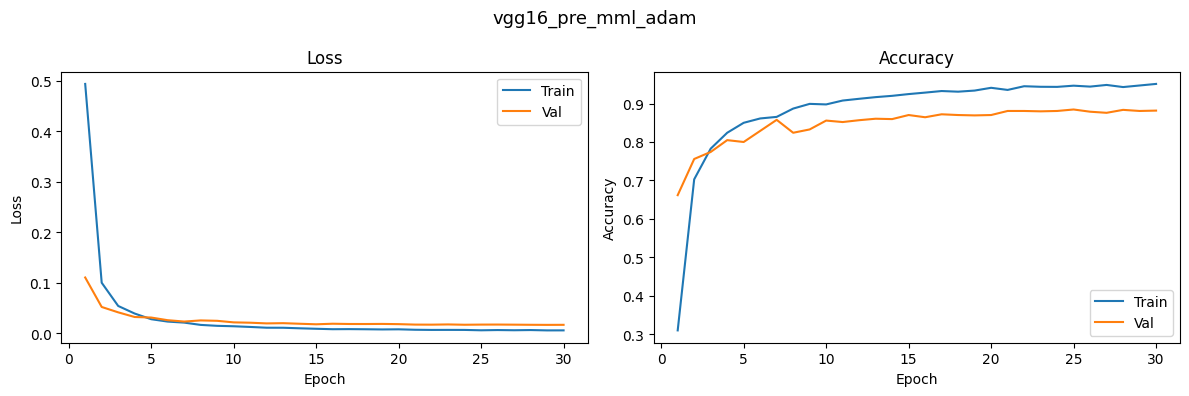


Run: vgg16_pre_mml_rmsprop
Loss: multi_margin  |  Optimizer: rmsprop  |  LR: 0.0001
Executando em: cpu
Epoch   1/30 | Train Loss: 0.3317 Acc: 0.3494 | Val Loss: 0.0555 Acc: 0.5990
Epoch   2/30 | Train Loss: 0.0480 Acc: 0.6381 | Val Loss: 0.0387 Acc: 0.7192
Epoch   3/30 | Train Loss: 0.0312 Acc: 0.7040 | Val Loss: 0.0298 Acc: 0.7385
Epoch   4/30 | Train Loss: 0.0242 Acc: 0.7490 | Val Loss: 0.0311 Acc: 0.7279
Epoch   5/30 | Train Loss: 0.0226 Acc: 0.7463 | Val Loss: 0.0292 Acc: 0.7625
Epoch   6/30 | Train Loss: 0.0185 Acc: 0.7798 | Val Loss: 0.0261 Acc: 0.7606
Epoch   7/30 | Train Loss: 0.0182 Acc: 0.7882 | Val Loss: 0.0249 Acc: 0.7981
Epoch   8/30 | Train Loss: 0.0161 Acc: 0.7987 | Val Loss: 0.0244 Acc: 0.8135
Epoch   9/30 | Train Loss: 0.0130 Acc: 0.8158 | Val Loss: 0.0268 Acc: 0.7971
Epoch  10/30 | Train Loss: 0.0113 Acc: 0.8327 | Val Loss: 0.0225 Acc: 0.7981
Epoch  11/30 | Train Loss: 0.0141 Acc: 0.8177 | Val Loss: 0.0237 Acc: 0.7971
Epoch  12/30 | Train Loss: 0.0123 Acc: 0.8379 | V

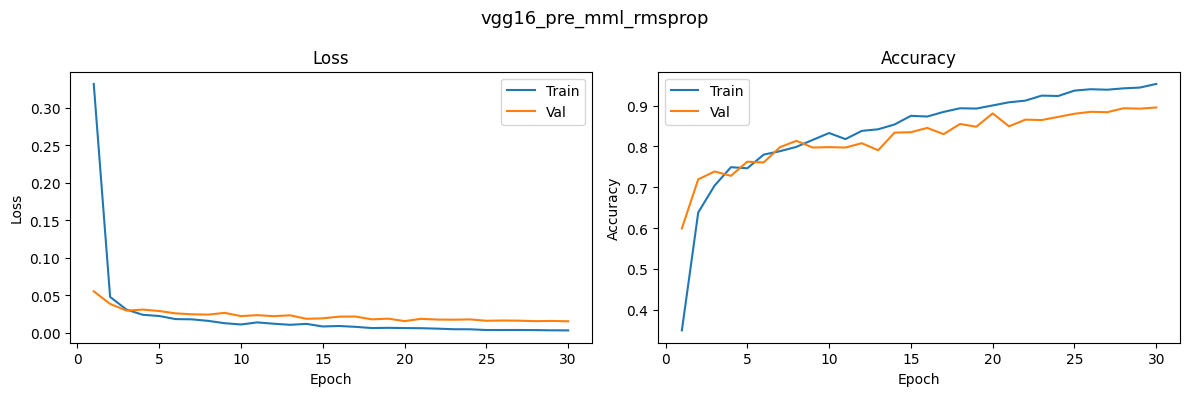


 TEMPOS DE EXECUÇÃO:
vgg16_pre_mml_adam -> 281.37 min
vgg16_pre_mml_rmsprop -> 280.27 min


In [16]:
results_summary = []
trained_models  = {}
all_histories   = {}
all_times       = {}

for run_name, model_fn, loss_name, optim_name, lr, epochs in experiments:
    print(f"\n{'='*60}")
    print(f"Run: {run_name}")
    print(f"Loss: {loss_name}  |  Optimizer: {optim_name}  |  LR: {lr}")
    print(f"{'='*60}")

    run_device = torch.device("cpu") if loss_name == "multi_margin" else device
    print(f"Executando em: {run_device}")

    model     = model_fn().to(run_device)
    criterion = build_criterion(loss_name)
    optimizer = build_optimizer(optim_name, model.parameters(), lr=lr)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)

    model, history, time_var = train_model(
        model, train_loader, val_loader, 
        criterion, optimizer, 
        scheduler=scheduler, 
        device=run_device, 
        run_name=run_name,
        num_epochs=epochs
    )

    _, _, labels, preds = evaluate(model, val_loader, criterion, run_device)
    metrics = compute_metrics(labels, preds, name=run_name)

    results_summary.append({
        "run"         : run_name,
        "loss"        : loss_name,
        "optimizer"   : optim_name,
        "lr"          : lr,
        "epochs"      : epochs,
        "time_min"    : round(time_var, 2),
        **metrics
    })
    
    trained_models[run_name] = model
    all_histories[run_name]  = history
    all_times[run_name]      = time_var

    plot_history(history, title=run_name)

    checkpoint_path = f"../checkpoints_CNN/checkpoints_{SEED}"
    os.makedirs(checkpoint_path, exist_ok=True)
    
    torch.save({
        "model_state": model.state_dict(), 
        "history": history,
        "metrics": metrics
    }, f"{checkpoint_path}/{run_name}.pt")

print("\n TEMPOS DE EXECUÇÃO:")
for key, value in all_times.items():
    print(f"{key} -> {value:.2f} min")